## Завантаження даних

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [3]:
df = pd.read_csv('bank-additional-full.csv',sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Exploratory Data Analysis

In [ ]:
df.shape

(41188, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Колонка pdays - 50%, 75% и max дорівнюють 999 і це означає що багатьом клієнтам не звонили.  
Колонка duration: медіана 180 секунд (3 хвилини), а max = 4918 (1,5 години) і це явний викид.  
Колонка campaign: 75% значень — до 3 дзвінків. max = 56 - теж викід.  

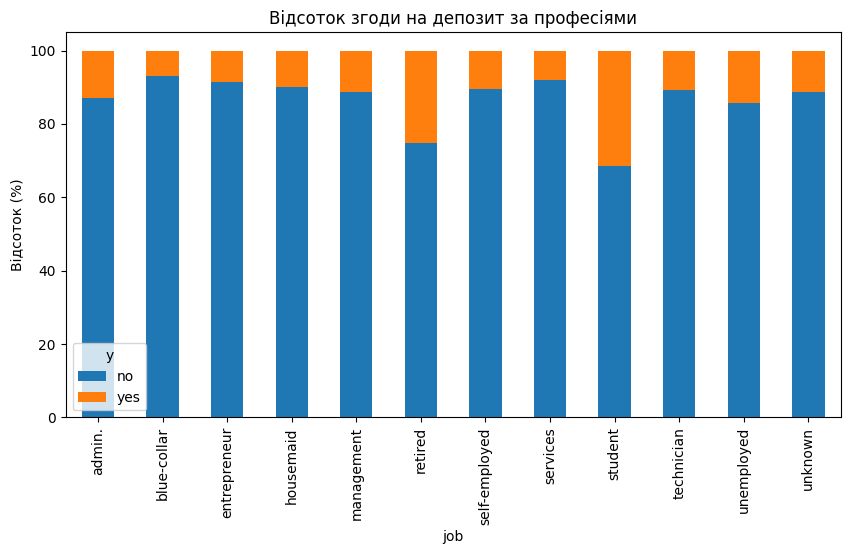

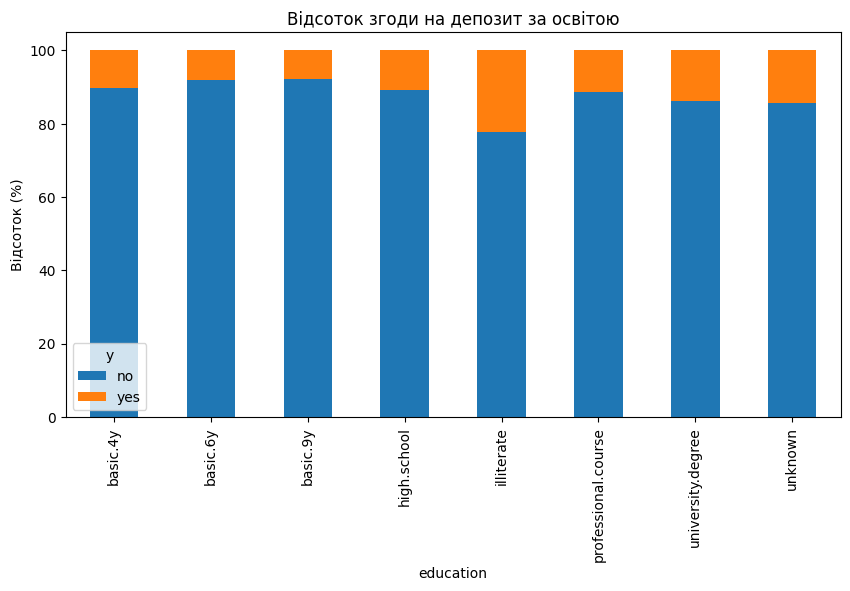

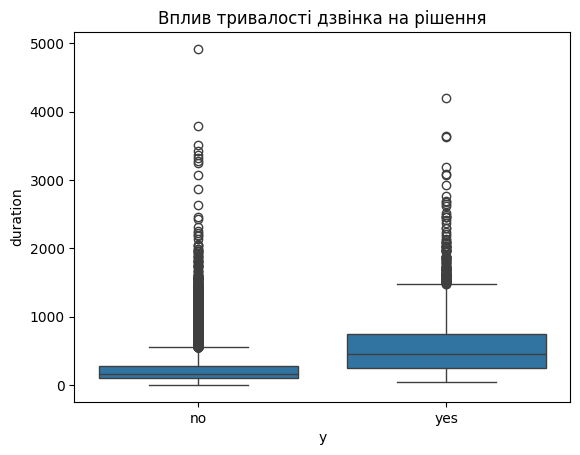

In [ ]:
# 1. Залежність згоди від професії (у відсотках)
job_y = pd.crosstab(df['job'], df['y'], normalize='index') * 100
job_y.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Відсоток згоди на депозит за професіями')
plt.ylabel('Відсоток (%)')
plt.show()

# 2. Залежність згоди від освіти (у відсотках)
educ_y = pd.crosstab(df['education'], df['y'], normalize='index') * 100
educ_y.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Відсоток згоди на депозит за освітою')
plt.ylabel('Відсоток (%)')
plt.show()

# 3. Тривалість дзвінка в залежності від відповіді
sns.boxplot(x='y', y='duration', data=df)
plt.title('Вплив тривалості дзвінка на рішення')
plt.show()

Графік професій: студенти (student) та пенсіонери (retired) беруть кредити частіше.

На діаграмі помаранчева частина (згода "yes") у них становить близько 25%, у той час як у робітників (blue-collar) або сервісу (services) конверсія менша.

Маркетинговому відділу банку вигідніше робити таргетовані кампанії саме на студентів та пенсіонерів.  

Якщо оператор утримує клієнта на лінії довше ніж 5 хвилин, шанс закрити угоду зростає в рази.

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    print(df[col].value_counts())
    print("\n")

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


contact
cellular     26144
telephone    15044
Name: coun

In [ ]:
# Рахуємо відсоток 'unknown' для всіх текстових колонок
for col in df.select_dtypes(include=['object']).columns:
    unknown_share = (df[col] == 'unknown').mean() * 100
    if unknown_share > 0:
        print(f"Колонка '{col}': {unknown_share:.2f}% значень 'unknown'")

Колонка 'job': 0.80% значень 'unknown'
Колонка 'marital': 0.19% значень 'unknown'
Колонка 'education': 4.20% значень 'unknown'
Колонка 'default': 20.87% значень 'unknown'
Колонка 'housing': 2.40% значень 'unknown'
Колонка 'loan': 2.40% значень 'unknown'


marital (0.19%), job (0.80%): маленький відсоток - міняємо на моду (mode()[0]).  
housing (2.40%), loan (2.40%), education (4.20%): більший відсоток, але це не критично - можна також замінити на моду.  
default (20.87%): досить великий відсоток, тож залишаємо 'unknown' як окрему категорію.

In [ ]:
(df['pdays'] == 999).mean()

np.float64(0.9632174419733903)

Має сенс зробити нову колонку з новою ознакою: 0 - раніше не дзвонили, 1 - дзвонили

In [ ]:
# співвідношення відповідей у ​​цільовій колонці y
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.887346
yes,0.112654


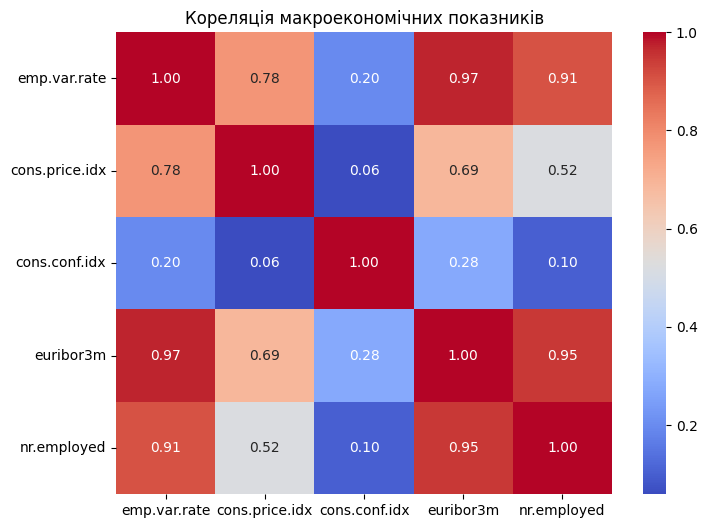

In [ ]:
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

corr_matrix = df[macro_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Кореляція макроекономічних показників')
plt.show()

Висока кореляція:  
euribor3m та emp.var.rate = 0.97  
euribor3m та nr.employed = 0.95  
emp.var.rate та nr.employed = 0.91  

Ці показники залежать один від одного, тож залишим тільки один показник euribor3m тому що від щоденний і дає показники на день звонка.

Маємо задачу бінарної класіфікації - відкриє кліент депозіт, чи ні. Для бінарної класифікації можна використати кілька моделей:  


1. Логістична регресія (Logistic Regression).
2. Дерева рішень та випадковий ліс (Random Forest).
3. Градієнтний бустинг (XGBoost / LightGBM / CatBoost).

У датасеті є гострий дисбаланс класів:  
no (не відкрили депозит) — 88.7%  
yes (відкрили депозит) — 11.3%

Якщо взяти метрику Accuracy, то модель матиме точнось 88.7%, якщо буде всім прогнозувати "no" - а це не підходить і модель буде не точною.

Так є ще такі метріки:

Precision (Точність): З усіх клієнтів, яких модель назвала потенційними покупцями (yes), скільки дійсно відкрили депозит?

Recall (Повнота): З усіх реальних клієнтів, які готові були відкрити депозит, скільки модель змогла знайти?

F1-Score: Середнє між Precision та Recall.

ROC-AUC (Area Under ROC Curve) - оцінює загальну здатність модели відрізняти клас yes від no незалежно від обраного порогу ймовірності.  

Тож за метрику буду брати загальний звіт по classification_report і ROC-AUC.

## Препроцесинг даних

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

In [5]:
df_cleaned = df.copy()
# Створюю бінарну ознаку для pdays
df_cleaned['pdays_contacted'] = (df_cleaned['pdays'] != 999).astype(int)

# Видаляю колонки
cols_to_drop = ['emp.var.rate', 'nr.employed', 'pdays']
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

In [6]:
#Розділення на X та y
X = df_cleaned.drop(columns=['y'])
y = df_cleaned['y'].map({'yes': 1, 'no': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Список колонок, де 'unknown' дуже мало і можу замінити їх на моду
low_unknown_cols = ['marital', 'job', 'housing', 'loan']

# Замінюю 'unknown' на моду для кожної з цих колонок
for col in low_unknown_cols:
    most_frequent = df_cleaned[col].mode()[0]
    X_train[col] = X_train[col].replace('unknown', most_frequent)
    X_test[col] = X_test[col].replace('unknown', most_frequent)

X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,pdays_contacted
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,0,nonexistent,93.200,-42.0,4.120,0
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,1,failure,93.200,-42.0,4.120,0
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,0,nonexistent,94.215,-40.3,0.870,0
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,0,nonexistent,93.994,-36.4,4.857,0
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,0,nonexistent,92.963,-40.8,1.262,0


In [7]:
ordinal_cols = ['education']
# Порядок категорій для education (від нижчого до вищого)
education_order = [[
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree', 'unknown'
]]
cat_cols = [col for col in X_train.select_dtypes(include=['object', 'category']).columns if col not in ordinal_cols]
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

**Виявлення та обробка викидів (Outliers)**:  
Під час первинного аналізу розподiлу числових ознак (df.describe()) було виявлено сильний правий зсув та наявність значних викидів у колонках `duration` (max = 4918 сек при 75%-му квантилі 319 сек) та `campaign` (max = 56 при 75%-му квантилі 3).  
Було прийнято рішення використати RobustScaler для масштабування тому що він більш стійкий до викидів.

In [8]:
# Пайплайн для числових колонок
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Пайплайн для категоріальних колонок
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False))
])

# Пайплайн для порядкової колонки education
ord_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=education_order))
])

# Всі Pipeline у ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
        ('ord', ord_pipeline, ordinal_cols)
    ],
    remainder='passthrough'  # Залишає без змін інші колонки (pdays_contacted)
)

## Тренування моделей

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [10]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])

# kNN Pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Decision Tree Pipeline
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [11]:
# Якість на 5 фолдах за метрикою ROC-AUC для Logistic Regression
cv_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Середній ROC-AUC (log_reg): {cv_scores.mean():.4f}")

# Оцінка kNN
knn_cv = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"kNN ROC-AUC: {knn_cv.mean():.4f}")

# Оцінка Decision Tree
tree_cv = cross_val_score(tree_pipeline, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Decision Tree ROC-AUC: {tree_cv.mean():.4f}")

Середній ROC-AUC (log_reg): 0.9295
kNN ROC-AUC: 0.8633
Decision Tree ROC-AUC: 0.7225


In [16]:
# глибина дерева
tree_pipeline.fit(X_train, y_train)
dt_model = tree_pipeline.named_steps['classifier']
print("Глибина звичайного дерева:", dt_model.get_depth())

Глибина звичайного дерева: 27


In [12]:
from sklearn.ensemble import GradientBoostingClassifier

# пайплайн для бустингу
boosting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Оцінка на крос-валідації
boosting_cv = cross_val_score(
    boosting_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Gradient Boosting ROC-AUC: {boosting_cv.mean():.4f}")

Gradient Boosting ROC-AUC: 0.9441


In [18]:
# глибина дерева на GradientBoosting
boosting_pipeline.fit(X_train, y_train)
gb_model = boosting_pipeline.named_steps['classifier']

first_tree = gb_model.estimators_[0, 0]

print("Глибина дерева в бустингу:", first_tree.get_depth())
print("Кількість дерев за замовчуванням:", gb_model.get_params()['n_estimators'])

Глибина дерева в бустингу: 3
Кількість дерев за замовчуванням: 100


### Порівняльний аналіз моделей (Cross-Validation ROC-AUC)

| Модель | Середній ROC-AUC | Оцінка та коментар |
| :--- | :---: | :--- |
| **Decision Tree** | 0.7225 | Перенавчання (Overfitting) без обмеження глибини `max_depth` |
| **kNN** | 0.8633 | Занадто велика кількість вимірів після One-Hot Encoding |
| **Logistic Regression** | 0.9295 | Високу точність з `RobustScaler` |
| **Gradient Boosting** | **0.9441** | **Найкращий результат** за рахунок послідовного виправлення помилок |

> **Висновок:** Для подальшого налаштування та підбору гіперпараметрів обираємо **Gradient Boosting**, оскільки він показав найвищу узагальнюючу здатність на крос-валідації.

## Тюнинг гіперпараметрів

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import randint, uniform

In [14]:
# Sklearn: Randomized Search
boosting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Сітка параметрів
param_distributions = {
    'classifier__n_estimators': randint(50, 200),        # кількість дерев
    'classifier__learning_rate': uniform(0.01, 0.2),     # швидкість навчання
    'classifier__max_depth': randint(3, 7),              # глибина дерев
    'classifier__subsample': uniform(0.7, 0.3)           # частка вибірки для кожного дерева
}

# RandomizedSearchCV (Випадковий пошук. Перебирає випадкові комбінації з заданої сітки)
random_search = RandomizedSearchCV(
    estimator=boosting_pipeline,
    param_distributions=param_distributions,
    n_iter=15,             # кількість випадкових комбінацій
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Запуск на X_train
random_search.fit(X_train, y_train)

print(f"Кращий ROC-AUC (RandomSearch): {random_search.best_score_:.4f}")
print("Кращі параметри:", random_search.best_params_)

Кращий ROC-AUC (RandomSearch): 0.9461
Кращі параметри: {'classifier__learning_rate': np.float64(0.046680901970686764), 'classifier__max_depth': 6, 'classifier__n_estimators': 107, 'classifier__subsample': np.float64(0.8574269294896713)}


In [19]:
# Hyperopt (Bayesian Optimization)
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# Простір пошуку (Search Space)
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 200, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'max_depth': hp.quniform('max_depth', 3, 7, 1),
    'subsample': hp.uniform('subsample', 0.7, 1.0)
}

def objective(space):
    params = {
        'n_estimators': int(space['n_estimators']),
        'learning_rate': space['learning_rate'],
        'max_depth': int(space['max_depth']),
        'subsample': space['subsample'],
        'random_state': 42
    }

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(**params))
    ])

    # Оцінюємо на 5 фолдах
    score = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()

    # Hyperopt МІНІМІЗУЄ значення, тому повертаємо -score
    return {'loss': -score, 'status': STATUS_OK}

# Баєсова оптимізація
trials = Trials()
best_hyperparams = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=15, # робимо ті ж 15 ітерацій для чесного порівняння
    trials=trials
)

# ROC-AUC
best_roc_auc_hyperopt = -min([t['result']['loss'] for t in trials.trials])

print(f"Кращий ROC-AUC (Hyperopt): {best_roc_auc_hyperopt:.4f}")
print("Кращі параметри (Hyperopt):", best_hyperparams)

100%|██████████| 15/15 [11:44<00:00, 47.00s/trial, best loss: -0.946106450830389]
Кращий ROC-AUC (Hyperopt): 0.9461
Кращі параметри (Hyperopt): {'learning_rate': np.float64(0.04888879998959342), 'max_depth': np.float64(6.0), 'n_estimators': np.float64(175.0), 'subsample': np.float64(0.9873829717886378)}


RandomizedSearchCV та Hyperopt дали однаковий ROC-AUC - 0.9461  
Обидва алгоритми знайшли дуже схожі глобальні налаштування (max_depth = 6, learning_rate ≈ 0.047–0.048)  
Оскільки RandomizedSearchCV знайшов аналогічну точність із меншою кількістю дерев (107 проти 175), то його модель є більш компактною та швидшою.

## Важливість ознак (Feature Importance)

In [20]:
best_pipeline = random_search.best_estimator_
preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['classifier']

feature_names = preprocessor.get_feature_names_out() # назви колонок після One-Hot Encoding

importances = model.feature_importances_

# DataFrame і сортування
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Tоп-10 найважливіших ознак
print(importance_df.head(10))

                  Feature  Importance
1           num__duration    0.450237
6          num__euribor3m    0.311954
0                num__age    0.036184
7    num__pdays_contacted    0.027337
4     num__cons.price.idx    0.024325
5      num__cons.conf.idx    0.021768
39  cat__poutcome_success    0.016373
30         cat__month_may    0.014510
2           num__campaign    0.013256
32         cat__month_oct    0.010742


**num__duration (45.0%)**: якщо людина слухає оператора - вона зацікавилася пропозицією. Якщо вона кладе трубку на 10-й секунді — відмова гарантована.  
**um__euribor3m (31%)**. Показує важливість впливу відсоткової ставки на ринку на відкриття депозитного вкладу.  
**num__age (3.6%)** та **num__pdays_contacted (2.7%)**: вік визначає фінансові можливості та накопичення (старші люди частіше тримають заощадження на депозитах). Факт попередніх успішних контактів показує лояльність клієнта.

## Фінальна перевірка на X_test

In [21]:
# Фінальна модель
best_model = random_search.best_estimator_

# Прогноз на X_test
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Метрики на тестовій вибірці
from sklearn.metrics import classification_report, roc_auc_score

print(f"Фінальний ROC-AUC на X_test: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Фінальний ROC-AUC на X_test: 0.9549

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      7310
           1       0.71      0.57      0.63       928

    accuracy                           0.93      8238
   macro avg       0.83      0.77      0.80      8238
weighted avg       0.92      0.93      0.92      8238



## Аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP

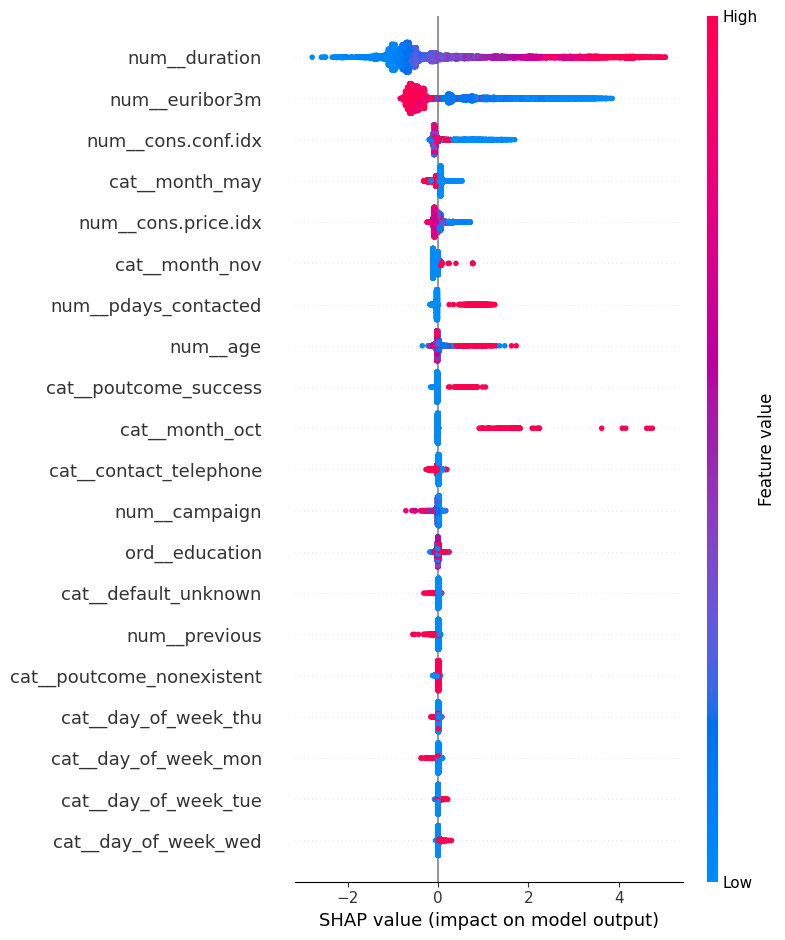

In [22]:
import shap

# Препроцесор та навчений бустинг - best_pipeline
preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['classifier']

# Трансформуємо X_test та отримуємо назви колонок
X_test_prepared = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Перетворюємо на DataFrame для гарного відображення в SHAP
X_test_df = pd.DataFrame(X_test_prepared, columns=feature_names)

# Створюємо SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_df)

# Головний графік SHAP (Summary Plot)
shap.summary_plot(shap_values, X_test_df)

Графік показує високе значення тривалості дзвінка, також якщо попередній контакт із клієнтом закінчився успіхом, це дає позитивний знак для прийняття рішення про депозит.  
По відсоткових ставках на ринку - навпаки низькі економічні ставки збільшують ймовірність згоди на депозит у тестовій вибірці.  
На навчальній вибірці num__euribor3m була другою за важливістю ознакою (близько 31% важливості). SHAP підтверджує її вагу, але додає напрямок впливу.

In [23]:
shap.initjs()

sample_size = 200 # випадкові 200 рідків
subset_indices = np.random.choice(X_test_df.shape[0], sample_size, replace=False)

shap_values_subset = shap_values[subset_indices]
X_test_subset = X_test_df.iloc[subset_indices]

shap.force_plot(
    explainer.expected_value,
    shap_values_subset.values,
    X_test_subset
)

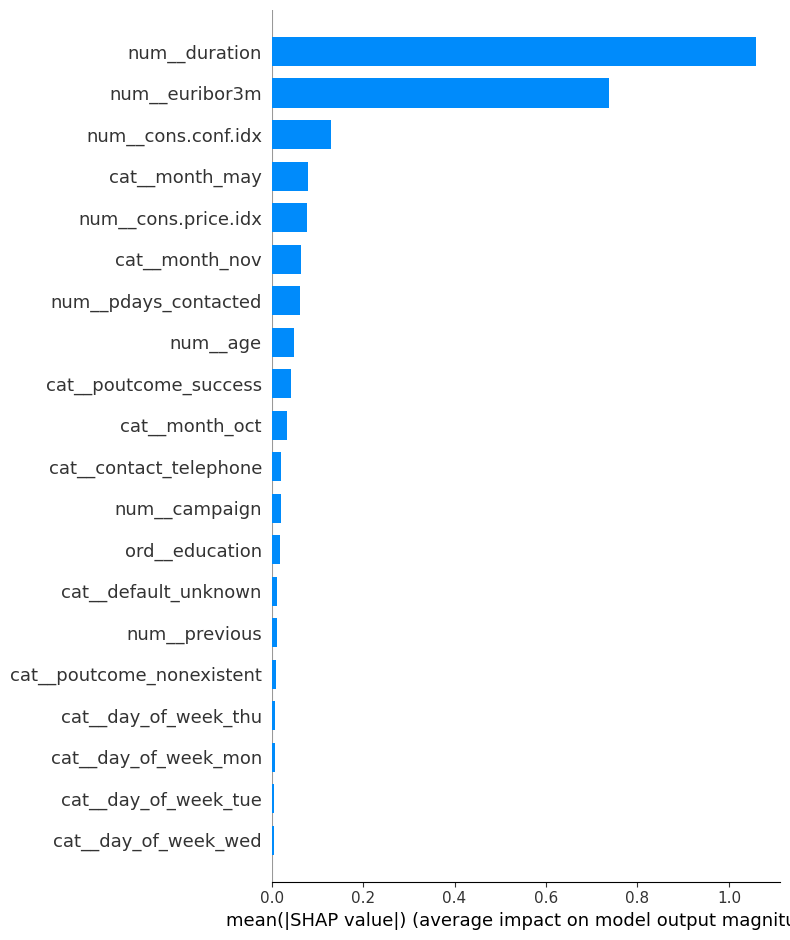

In [26]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

## Аналіз помилок (Error Analysis)

In [27]:
results_df = X_test.copy()
results_df['y_true'] = y_test
results_df['y_pred'] = y_pred
results_df['y_proba'] = y_proba

# Фільтр записів, де модель помилилася
errors_df = results_df[results_df['y_true'] != results_df['y_pred']]

# Розділяємо на FP та FN
false_positives = results_df[(results_df['y_true'] == 0) & (results_df['y_pred'] == 1)]
false_negatives = results_df[(results_df['y_true'] == 1) & (results_df['y_pred'] == 0)]

print(f"Всього помилок: {len(errors_df)} з {len(X_test)}")
print(f"False Positives (зайві дзвінки): {len(false_positives)}")
print(f"False Negatives (втрачені клієнти): {len(false_negatives)}")

Всього помилок: 615 з 8238
False Positives (зайві дзвінки): 219
False Negatives (втрачені клієнти): 396


In [28]:
# Порівняємо середню тривалість дзвінка та макро-показники
comparison = pd.DataFrame({
    'Correct_Predictions': results_df[results_df['y_true'] == results_df['y_pred']][['duration', 'euribor3m', 'age']].mean(),
    'False_Positives': false_positives[['duration', 'euribor3m', 'age']].mean(),
    'False_Negatives': false_negatives[['duration', 'euribor3m', 'age']].mean()
})

print(comparison)

           Correct_Predictions  False_Positives  False_Negatives
duration            235.855437       714.611872       450.800505
euribor3m             3.737023         2.164297         2.440121
age                  39.987275        41.607306        40.684343


Модель має сильну залежність від тривалості дзвінока. Коли дзвінок довгий, але в результаті відмова - модель видає хибний позитивний прогноз. Можливо варто було перенавчити модель без застосування ознаки duration. Це може знизити ROC-AUC, але дати можливість відділу маркетингу передбачати якому клієнту варто дзвонити.
